<a href="https://colab.research.google.com/github/Maryjancy894/INTERNSHIP/blob/main/K_Means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
data = load_breast_cancer()
X = data.data
y = data.target  # (optional, only for reference)

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [4]:
inertia = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

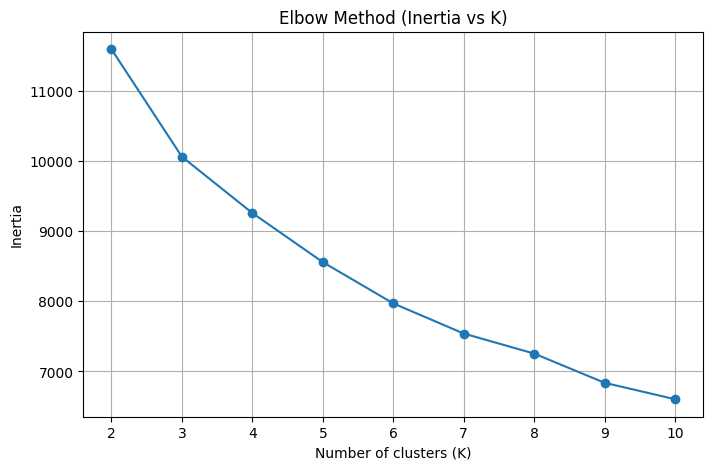

In [5]:
plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.title("Elbow Method (Inertia vs K)")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.grid()
plt.show()

In [6]:
sil_scores = []

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)
    print("K =", k, "Silhouette Score =", round(score, 4))

K = 2 Silhouette Score = 0.3434
K = 3 Silhouette Score = 0.3144
K = 4 Silhouette Score = 0.2833
K = 5 Silhouette Score = 0.1582
K = 6 Silhouette Score = 0.1604
K = 7 Silhouette Score = 0.1532
K = 8 Silhouette Score = 0.1472
K = 9 Silhouette Score = 0.147
K = 10 Silhouette Score = 0.1367


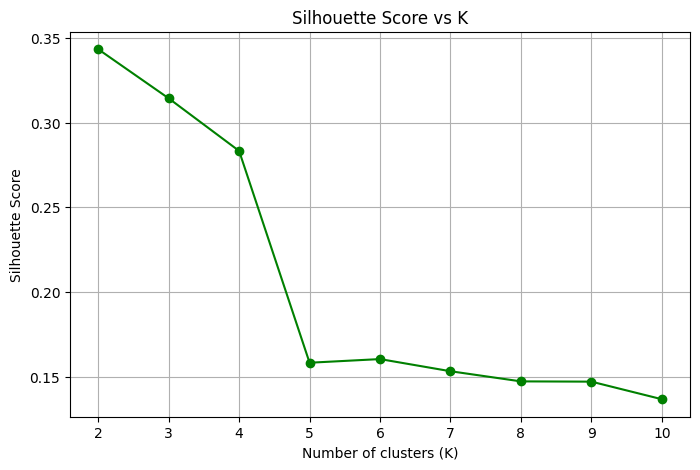

In [7]:
plt.figure(figsize=(8,5))
plt.plot(K, sil_scores, marker='o', color='green')
plt.title("Silhouette Score vs K")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.grid()
plt.show()

In [8]:
best_k = 2   # usually 2 for breast cancer dataset
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

In [9]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

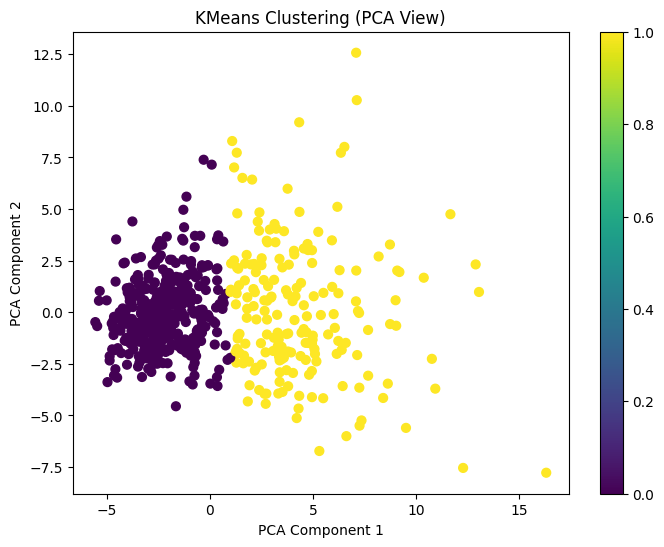

In [11]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='viridis', s=40)
plt.title("KMeans Clustering (PCA View)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar()
plt.show()

In [12]:
print("Final Inertia:", kmeans.inertia_)
print("Final Silhouette Score:", silhouette_score(X_scaled, labels))

Final Inertia: 11595.526607115773
Final Silhouette Score: 0.34338224069077816
